# Financial News - Preprocessing for word2vec

The data is avaialble from [Kaggle](https://www.kaggle.com/jeet2016/us-financial-news-articles). 

Download and unzip into data directory in repository root folder, then rename the enclosing folder to `us-financial-news` and the subfolders so you get the following directory structure:
```
data
  |-us-financial-news
     |-2018_01
     |-2018_02
     |-2018_03
     |-2018_04
     |-2018_05
```

## Imports

In [1]:
import os, tarfile, sys, json
from pathlib import Path
from time import time
from pprint import pprint
from collections import Counter

import numpy as np
from numpy.random import choice
import pandas as pd
import seaborn as sns

import spacy
from spacy.lang.en import English

from gensim.models.word2vec import LineSentence
from gensim.models.phrases import Phrases, Phraser

print("Import done!")

Import done!


### Settings

In [2]:
pd.set_option('float_format', '{:,.2f}'.format)
sns.set_style('white')
np.random.seed(42)

In [3]:
def format_time(t):
    m, s = divmod(t, 60)
    h, m = divmod(m, 60)
    return '{:02.0f}:{:02.0f}:{:02.0f}'.format(h, m, s)

In [4]:
stop_words_url = "http://ir.dcs.gla.ac.uk/resources/linguistic_utils/stop_words"

stop_words = pd.read_csv(
    stop_words_url,
    header=None,
    names=["word"]
)["word"]

stop_words = (
    stop_words
    .dropna()
    .astype(str)
    .str.strip()
)

stop_words = set(stop_words[stop_words != ""])

len(stop_words)

319

### Paths

In [5]:
data_path = Path('c:/', 'data','sandbox', 'us-financial-news')
print(data_path)

c:\data\sandbox\us-financial-news


In [6]:
results_path = Path('c:/', 'data','sandbox','results', 'financial_news')
if not results_path.exists():
    results_path.mkdir(exist_ok=True)
print(results_path)

c:\data\sandbox\results\financial_news


In [8]:
article_path       = results_path / 'articles.txt'
clean_article_path = results_path / 'articles_clean.txt'
print(article_path)
print(clean_article_path)

c:\data\sandbox\results\financial_news\articles.txt
c:\data\sandbox\results\financial_news\articles_clean.txt


## Load Data

We limit the article selection to the following sections in the dataset:

In [9]:
section_titles = ['Press Releases - CNBC',
                  'Reuters: Company News',
                  'Reuters: World News',
                  'Reuters: Business News',
                  'Reuters: Financial Services and Real Estate',
                  'Top News and Analysis (pro)',
                  'Reuters: Top News',
                  'The Wall Street Journal &amp; Breaking News, Business, Financial and Economic News, World News and Video',
                  'Business &amp; Financial News, U.S &amp; International Breaking News | Reuters',
                  'Reuters: Money News', 'Reuters: Technology News']

In [10]:
def read_articles():
    articles = []
    counter = Counter()
    
    for f in data_path.glob('*/**/*.json'):
        
        # Explicitly open the JSON file using UTF-8 encoding.
        # This avoids Windows default encoding issues, such as cp1252 errors.
        with f.open("r", encoding="utf-8") as file:
            article = json.load(file)
        
        if article['thread']['section_title'] in set(section_titles):
            text = article['text'].lower().split()
            counter.update(text)
            articles.append(' '.join([t for t in text if t not in stop_words]))
    
    return articles, counter

In [11]:
articles, counter = read_articles()
print(f'Done loading {len(articles):,.0f} articles')

Done loading 125,964 articles


In [12]:
print(article_path)

c:\data\sandbox\results\financial_news\articles.txt


In [50]:
# Save all cleaned articles into a text file.
# We explicitly use UTF-8 to avoid Windows cp1252 encoding errors.
article_path.write_text(
    '\n'.join(articles),
    encoding='utf-8'
)

418422851

## Clean Financial News Articles

In [23]:
articles = article_path.read_text(encoding='utf-8').splitlines()
len(articles)

125964

### Sentence Boundary Detection

In [51]:
def clean_doc(d):
    """
    Clean a spaCy document by extracting clean sentence-level text.

    Parameters
    ----------
    d : spacy.tokens.Doc
        A spaCy Doc object. The document must already have sentence boundaries,
        meaning that d.sents must be available.

    Returns
    -------
    doc : list of str
        A list of cleaned sentences. Each sentence is returned as a single
        lowercase string, where tokens are separated by spaces.
    """

    # This list will contain the cleaned sentences extracted from the document.
    doc = []

    # Iterate over the sentences detected by spaCy.
    # Each 'sent' is a Span object representing one sentence.
    for sent in d.sents:

        # Build a cleaned list of tokens for the current sentence.
        #
        # For each token t in the sentence, we keep only tokens satisfying:
        #
        # 1. t is not a digit
        # 2. t is alphabetic
        # 3. t is not punctuation
        # 4. t is not whitespace
        #
        # The original compact condition was:
        #
        #     if not any([t.is_digit, not t.is_alpha, t.is_punct, t.is_space])
        #
        # This means:
        #
        #     keep the token only if none of those unwanted conditions is True.
        #
        # In simpler terms, the token is kept only if it is a normal alphabetic word.
        #
        # The token text is also converted to lowercase.
        s = [
            t.text.lower()
            for t in sent
            if not any([
                t.is_digit,       # Exclude tokens consisting of digits
                not t.is_alpha,   # Exclude non-alphabetic tokens
                t.is_punct,       # Exclude punctuation
                t.is_space        # Exclude whitespace tokens
            ])
        ]

        # Decide whether to keep the cleaned sentence.
        #
        if len(s) > 5 and len(sent) < 100:

            # Join the cleaned tokens into a single string.
            #
            # Example:
            #
            #     ['financial', 'markets', 'rose', 'today']
            #
            # becomes:
            #
            #     'financial markets rose today'
            doc.append(' '.join(s))

    # Return the list of cleaned sentence strings.
    return doc

In [52]:
import spacy

# Create a blank English pipeline.
nlp = spacy.blank("en")

# Add the rule-based sentence segmenter.
nlp.add_pipe("sentencizer")

In [53]:
clean_articles = []
iter_articles = (article for article in articles)
for i, doc in enumerate(nlp.pipe(iter_articles, batch_size=100, n_process=8), 1):
    if i % int(len(articles) / 100) + 1 == 0:
        print(f'{i / len(articles):.1%}', end=' ', flush=True)
    clean_articles.extend(clean_doc(doc))

In [27]:
clean_article_path.write_text(
    '\n'.join(clean_articles),
    encoding='utf-8'
)

356895840

### Corpus Stats

In [28]:
len(clean_articles)

2982031

In [29]:
vocab = Counter()
sent_length = []
for sentence in clean_articles:
    tokens = sentence.lower().split()
    sent_length.append(len(tokens))
    vocab.update(tokens)

In [30]:
len(sent_length)

2982031

In [31]:
pd.Series(sent_length).describe(percentiles=np.arange(.1, 1, .1).round(1))

count   2,982,031.00
mean           15.40
std            20.75
min             0.00
10%             4.00
20%             6.00
30%             8.00
40%            10.00
50%            12.00
60%            14.00
70%            17.00
80%            20.00
90%            25.00
max         6,910.00
dtype: float64

In [32]:
most_common = (pd.DataFrame(vocab.most_common(), columns=['token', 'count'])
               .pipe(lambda x: x[~x.token.str.lower().isin(stop_words)]))

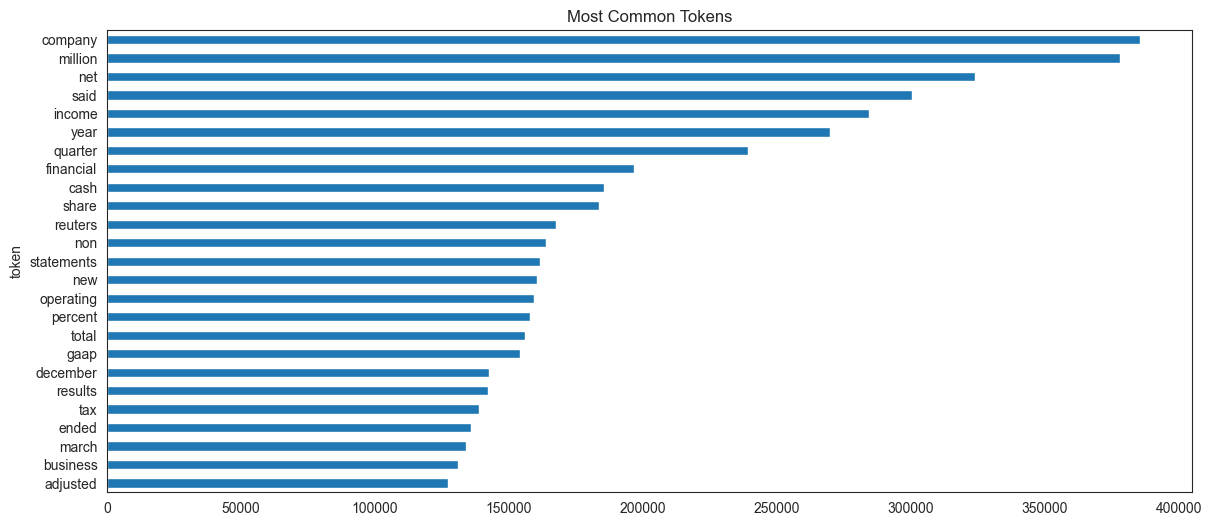

In [33]:
most_common.head(25).set_index('token')['count'].sort_values().plot.barh(title='Most Common Tokens', figsize=(14, 6));

### Inspect Result

In [34]:
clean_articles[:3]

['hours ago emerging markets soared percent todd gordon says rally wo stop',
 'big rally emerging markets tracked emerging market etf eem weak dollar',
 'given gordon sees inverse relationship eem dollar measured charts dollar tracking etf uup believes']

## Create n-grams

### `articles_2_grams.txt` vs `articles_3_grams.txt` — What Changes and Why

The two files are produced by the same iterative loop but represent
**different levels of collocation merging**. Understanding the difference
requires understanding what Gensim's `Phrases` model actually does.

---

#### What `Phrases` does

`Phrases` scans the corpus and identifies pairs of adjacent tokens that
co-occur significantly more often than chance. For each candidate pair
$(w_1, w_2)$ it computes a **collocation score** (a variant of
pointwise mutual information). If the score exceeds `threshold=100`
and the pair appears at least `min_count=10` times, the two tokens are
merged into a single token joined by an underscore.

*Example:*

```
"interest rate decision"  →  "interest_rate decision"
```

---

#### Pass 1 → `articles_2_grams.txt`

The input is `articles_clean.txt` — one cleaned sentence per line, all
tokens still separate. `Phrases` scans this file and merges **adjacent
token pairs** that pass the threshold.

Result: frequent two-word financial expressions become single tokens.

| Before (clean) | After (2-grams) |
|---|---|
| `interest rate` | `interest_rate` |
| `central bank` | `central_bank` |
| `hedge fund` | `hedge_fund` |
| `earnings per` | `earnings_per` |

Every sentence in `articles_2_grams.txt` is identical to the clean
version **except** where a qualifying bigram was found — those two
tokens are replaced by one compound token.

---

#### Pass 2 → `articles_3_grams.txt`

Crucially, the **input to the second pass is `articles_2_grams.txt`**,
not the original clean file. This is the key line in the code:

```python
if n > 2:
    sentences = LineSentence(
        results_path / f'articles_{n-1}_grams.txt'
    )
```

`Phrases` now sees the already-merged corpus. Tokens like
`interest_rate` and `earnings_per` are treated as single atomic units.
The model looks for adjacent pairs again — but now a "pair" can be
**(bigram + word)** or **(word + bigram)**.

Result: three-word financial expressions become single tokens.

| In 2-gram file | After (3-grams) |
|---|---|
| `interest_rate decision` | `interest_rate_decision` |
| `earnings_per share` | `earnings_per_share` |
| `federal_reserve bank` | `federal_reserve_bank` |
| `real_estate investment` | `real_estate_investment` |

---

#### Why it matters for Word2Vec

Word2Vec treats each whitespace-separated token as one unit. Without
n-gram merging, the model sees three separate signals:

```
"federal"  "reserve"  "bank"
```

and learns three independent vectors with no guarantee that their
combination captures the concept *Federal Reserve Bank* as a whole.

With trigram merging, the model sees one atomic token:

```
"federal_reserve_bank"
```

and learns a **single vector** that directly encodes the concept.
This is especially valuable for financial text, where multi-word
expressions — `central_bank`, `interest_rate_decision`,
`earnings_per_share` — carry specific, irreducible meaning that
cannot be reliably reconstructed from their component words.

---

#### Summary

| Property | `articles_2_grams.txt` | `articles_3_grams.txt` |
|---|---|---|
| Input | `articles_clean.txt` | `articles_2_grams.txt` |
| Merges | Adjacent word pairs | Adjacent word + bigram |
| Max compound length | 2 tokens | 3 tokens |
| Used for training? | Intermediate file | ✓ Direct input to Word2Vec |

`articles_2_grams.txt` is an **intermediate artefact** — it exists
so that the second `Phrases` pass can see already-merged bigrams as
atomic units. The file actually fed into Word2Vec training is always
`articles_3_grams.txt`.
```

In [35]:
max_length = 3

In [36]:
n_grams = pd.DataFrame()
start = time()

sentences = LineSentence(clean_article_path.as_posix())

for n in range(2, max_length + 1):
    
    print(n, end=' ')
    
    if n > 2:
        sentences = LineSentence(
            (results_path / f'articles_{n-1}_grams.txt').as_posix()
        )
    
    phrases = Phrases(
        sentences,
        threshold=100,
        min_count=10
    )

    # Modern Gensim API:
    # find_phrases(sentences) returns a dictionary:
    # {phrase: score}
    phrase_scores = phrases.find_phrases(sentences)

    # Convert the dictionary directly into a DataFrame.
    # At this point s is already a DataFrame.
    s = (
        pd.Series(phrase_scores, name="score")
          .rename_axis("phrase")
          .reset_index()
          .assign(length=n)
    )

    n_grams = pd.concat([n_grams, s], ignore_index=True)

    grams = Phraser(phrases)
    sentences = grams[sentences]

    with (results_path / f'articles_{n}_grams.txt').open(
        'w',
        encoding='utf-8'
    ) as f:
        for sentence in sentences:
            f.write(' '.join(sentence) + '\n')

n_grams = n_grams.sort_values('score', ascending=False)

n_grams["phrase"] = n_grams["phrase"].str.replace('_', ' ', regex=False)
n_grams["ngram"] = n_grams["phrase"].str.replace(' ', '_', regex=False)

print('\n\tDuration: ', format_time(time() - start))
print(f'\tngrams: {len(n_grams):,d}\n')
print(n_grams.groupby('length').size())

2 3 
	Duration:  00:11:14
	ngrams: 43,700

length
2    26978
3    16722
dtype: int64


In [37]:
n_grams.groupby('length').apply(lambda x: x.nlargest(10, 'score'))

C:\Users\User\AppData\Local\Temp\ipykernel_23092\3953190172.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  n_grams.groupby('length').apply(lambda x: x.nlargest(10, 'score'))


phrase      score  length  \
length                                                                 
2      23238           mukhammadsharif mamatkulov 182,440.40       2   
       10910                pracha hariraksapitak 182,440.40       2   
       17105                        citigate dewe 182,440.40       2   
       12383             hidradenitis suppurativa 182,440.40       2   
       26634                         nidaa tounes 182,026.70       2   
       21864               axalimogene filolisbac 182,026.70       2   
       19187                      koustav samanta 182,026.70       2   
       24795                     navesh chitrakar 182,026.70       2   
       25263              munkhchimeg davaasharav 181,935.02       2   
       12054                      ishita chigilli 181,935.02       2   
3      34482          hgst sandisk tegile upthere 189,439.70       3   
       40535       freshfields bruckhaus deringer 189,439.70       3   
       30337  daniela palmieri jessica fitzgerald 189,439.70       3   
       41133                 dana reizniece ozola 189,439.70       3   
       35447             writing fransiska nangoy 189,439.70       3   
       32377   strategist janney montgomery scott 189,439.70       3   
       40681       carson elder beerman herberger 189,439.70       3   
       35674              economist dai ichi life 189,010.13       3   
       38500                         fmt hst fsdp 189,010.13       3   
       40839        hormone transcon pth transcon 189,010.13       3   

                                            ngram  
length                                             
2      23238           mukhammadsharif_mamatkulov  
       10910                pracha_hariraksapitak  
       17105                        citigate_dewe  
       12383             hidradenitis_suppurativa  
       26634                         nidaa_tounes  
       21864               axalimogene_filolisbac  
       19187                      koustav_samanta  
       24795                     navesh_chitrakar  
       25263              munkhchimeg_davaasharav  
       12054                      ishita_chigilli  
3      34482          hgst_sandisk_tegile_upthere  
       40535       freshfields_bruckhaus_deringer  
       30337  daniela_palmieri_jessica_fitzgerald  
       41133                 dana_reizniece_ozola  
       35447             writing_fransiska_nangoy  
       32377   strategist_janney_montgomery_scott  
       40681       carson_elder_beerman_herberger  
       35674              economist_dai_ichi_life  
       38500                         fmt_hst_fsdp  
       40839        hormone_transcon_pth_transcon